# Heat Risk Bangkok — PyTorch LSTM
**พื้นที่:** กรุงเทพมหานคร 50 เขต  
**ข้อมูล:** Open-Meteo Historical API (2014–2023, 10 ปี)  
**โมเดล:** LSTM Multi-step (168h input → 24h forecast)  
**GPU:** RTX 5060 / CUDA 12.9 (Blackwell sm_120)

---
## Step 1 — Import Libraries & GPU Check

In [4]:
import os, time, json, pickle, zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── GPU ────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU   : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA  : {torch.version.cuda}")
    print(f"  VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ไม่พบ GPU — ใช้ CPU (train ช้ากว่า)")

Device : cuda
  GPU   : NVIDIA GeForce RTX 5060 Laptop GPU
  CUDA  : 12.8
  VRAM  : 8.5 GB


---
## Step 2 — Config & File Paths

In [5]:
# ── ปรับ path ให้ตรงกับโฟลเดอร์ของคุณ ────────────────────────
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))

BOUNDARY_FILE   = os.path.join(BASE_DIR, 'bangkok_district.geojson')  # ใช้ GeoJSON ที่โหลดมาใหม่
POPULATION_FILE = os.path.join(BASE_DIR, 'bkk_60_up.csv')

# ── โหลด GeoJSON → GeoDataFrame ──────────────────────────────
boundary = gpd.read_file(BOUNDARY_FILE)
if boundary.crs is None:
    boundary = boundary.set_crs(epsg=4326)
else:
    boundary = boundary.to_crs(epsg=4326)

print(f"Boundary : {len(boundary)} เขต  CRS={boundary.crs}")
print("Columns  :", boundary.columns.tolist())
display(boundary[['dname','dcode','geometry']].head(3))

# ── โหลด Population ─────────────────────────────────────────
pop_raw = pd.read_csv(POPULATION_FILE, encoding='utf-8-sig')
pop_raw = pop_raw[pop_raw['อำเภอ'].str.startswith('เขต')].reset_index(drop=True)
print(f"\nPopulation: {len(pop_raw)} เขต")
print("Columns   :", pop_raw.columns[:5].tolist(), "...")
display(pop_raw[['อำเภอ','ชายรวม','หญิงรวม','รวมทั้งหมด']].head(5))

Boundary : 50 เขต  CRS=EPSG:4326
Columns  : ['AREA', 'dcode', 'dname', 'dname_e', 'geometry']


,dname,dcode,geometry
0,เขตบางพลัด,1025,"POLYGON ((100.51636 13.80039, 100.51636 13.799..."
1,เขตห้วยขวาง,1017,"POLYGON ((100.58855 13.80316, 100.58855 13.802..."
2,เขตวังทองหลาง,1045,"POLYGON ((100.61303 13.79485, 100.61303 13.795..."



Population: 50 เขต
Columns   : ['อำเภอ', 'ชาย60 ปี', 'หญิง60 ปี', 'ชาย61 ปี', 'หญิง61 ปี'] ...


,อำเภอ,ชายรวม,หญิงรวม,รวมทั้งหมด
0,เขตพระนคร,"5,499","7,429","12,928"
1,เขตดุสิต,"10,183","12,552","22,735"
2,เขตหนองจอก,"11,845","14,504","26,349"
3,เขตบางรัก,"4,157","6,521","10,678"
4,เขตบางเขน,"16,281","23,763","40,044"


---
## Step 3 — กำหนด 5 โซนกรุงเทพ (แทน 5 โซนเชียงใหม่)

In [6]:
# กรุงเทพอยู่ที่ระดับความสูง 2–6 เมตรเหนือน้ำทะเล
# แบ่ง 5 โซนตามทิศ เพื่อจับ Urban Heat Island ที่แตกต่างกัน

ZONES = [
    # (ชื่อโซน,  lat,      lon,      elevation_m)
    ("ใจกลาง",   13.7520,  100.4940,  4),   # พระนคร, ปทุมวัน, สาทร
    ("เหนือ",    13.9000,  100.5700,  6),   # ดอนเมือง, หลักสี่, สายไหม
    ("ใต้",      13.6200,  100.5300,  2),   # ราษฎร์บูรณะ, จอมทอง, ทุ่งครุ
    ("ตะวันออก", 13.7500,  100.7500,  3),   # ลาดกระบัง, มีนบุรี, คลองสามวา
    ("ตะวันตก",  13.7500,  100.3800,  5),   # ตลิ่งชัน, ทวีวัฒนา, บางแค
]

START_DATE = "2014-01-01"
END_DATE   = "2023-12-31"
CACHE_FILE = "weather_cache_bkk.pkl"   # cache แยกจากเชียงใหม่

print("5 โซนกรุงเทพ:")
for name, lat, lon, elev in ZONES:
    print(f"  {name:12s}  lat={lat}  lon={lon}  elev={elev}m")
print(f"\nช่วงข้อมูล: {START_DATE} ถึง {END_DATE} (10 ปี)")
print(f"คาดว่ามี ~{10*365*24*len(ZONES):,} rows")

5 โซนกรุงเทพ:
  ใจกลาง        lat=13.752  lon=100.494  elev=4m
  เหนือ         lat=13.9  lon=100.57  elev=6m
  ใต้           lat=13.62  lon=100.53  elev=2m
  ตะวันออก      lat=13.75  lon=100.75  elev=3m
  ตะวันตก       lat=13.75  lon=100.38  elev=5m

ช่วงข้อมูล: 2014-01-01 ถึง 2023-12-31 (10 ปี)
คาดว่ามี ~438,000 rows


---
## Step 4 — ดึงข้อมูลอากาศ Open-Meteo (Cache)

In [7]:
if os.path.exists(CACHE_FILE):
    print("โหลดจาก cache...")
    with open(CACHE_FILE, 'rb') as f:
        df_raw = pickle.load(f)
    print(f"โหลด cache สำเร็จ: {len(df_raw):,} rows")
else:
    print("ดึงข้อมูลใหม่จาก Open-Meteo (ใช้เวลา ~5-10 นาที)...")
    dfs_all = []
    for zone_name, lat, lon, elev in ZONES:
        print(f"  ดึงโซน '{zone_name}' ({lat}, {lon})...", end=" ", flush=True)
        t0 = time.time()
        r = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude":              lat,
                "longitude":             lon,
                "start_date":            START_DATE,
                "end_date":              END_DATE,
                "hourly":                "temperature_2m,relative_humidity_2m,wind_speed_10m",
                "timezone":              "Asia/Bangkok",
                "wind_speed_unit":       "kmh",
            },
            timeout=120
        )
        r.raise_for_status()
        js = r.json()

        df_z = pd.DataFrame({
            "time":                 pd.to_datetime(js["hourly"]["time"]),
            "temperature_2m":       js["hourly"]["temperature_2m"],
            "relative_humidity_2m": js["hourly"]["relative_humidity_2m"],
            "wind_speed_10m":       js["hourly"]["wind_speed_10m"],
        })
        df_z["zone"]      = zone_name
        df_z["elevation"] = elev
        dfs_all.append(df_z)
        print(f"{len(df_z):,} rows ({time.time()-t0:.1f}s)")

    df_raw = pd.concat(dfs_all, ignore_index=True)
    df_raw.dropna(subset=["temperature_2m","relative_humidity_2m"], inplace=True)
    df_raw.reset_index(drop=True, inplace=True)

    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(df_raw, f)
    print(f"\nบันทึก cache: {len(df_raw):,} rows → {CACHE_FILE}")

print(f"\nShape  : {df_raw.shape}")
print(f"Zones  : {df_raw['zone'].unique()}")
print(f"Period : {df_raw['time'].min()} — {df_raw['time'].max()}")
print(f"Temp   : {df_raw['temperature_2m'].min():.1f} — {df_raw['temperature_2m'].max():.1f} °C")
print(f"RH     : {df_raw['relative_humidity_2m'].min():.0f} — {df_raw['relative_humidity_2m'].max():.0f} %")
display(df_raw.head(3))

ดึงข้อมูลใหม่จาก Open-Meteo (ใช้เวลา ~5-10 นาที)...
  ดึงโซน 'ใจกลาง' (13.752, 100.494)... 87,648 rows (3.0s)
  ดึงโซน 'เหนือ' (13.9, 100.57)... 87,648 rows (2.7s)
  ดึงโซน 'ใต้' (13.62, 100.53)... 87,648 rows (2.7s)
  ดึงโซน 'ตะวันออก' (13.75, 100.75)... 87,648 rows (2.7s)
  ดึงโซน 'ตะวันตก' (13.75, 100.38)... 87,648 rows (2.7s)

บันทึก cache: 438,240 rows → weather_cache_bkk.pkl

Shape  : (438240, 6)
Zones  : <StringArray>
['ใจกลาง', 'เหนือ', 'ใต้', 'ตะวันออก', 'ตะวันตก']
Length: 5, dtype: str
Period : 2014-01-01 00:00:00 — 2023-12-31 23:00:00
Temp   : 12.9 — 39.8 °C
RH     : 17 — 100 %


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,zone,elevation
0,2014-01-01 00:00:00,20.8,71,6.2,ใจกลาง,4
1,2014-01-01 01:00:00,20.2,74,6.1,ใจกลาง,4
2,2014-01-01 02:00:00,19.6,79,6.0,ใจกลาง,4


---
## Step 5 — Feature Engineering

In [8]:
def calc_heat_index(T, RH):
    """Steadman Simplified — กรมอุตุนิยมวิทยาไทย (เขตร้อนชื้น)"""
    return T + 0.55 * (1.0 - RH / 100.0) * (T - 14.5)

df = df_raw.copy()
df["heat_index"]     = calc_heat_index(df["temperature_2m"], df["relative_humidity_2m"])
df["hour"]           = df["time"].dt.hour
df["day_of_year"]    = df["time"].dt.dayofyear

# Cyclic encoding
df["sin_hour"]       = np.sin(2 * np.pi * df["hour"]        / 24)
df["cos_hour"]       = np.cos(2 * np.pi * df["hour"]        / 24)
df["sin_doy"]        = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_doy"]        = np.cos(2 * np.pi * df["day_of_year"] / 365)

# กรุงเทพระดับน้ำสูงมากที่สุดแค่ 6m → normalize ด้วย max ของ dataset
df["elevation_norm"] = df["elevation"] / df["elevation"].max()

zone_list = [z[0] for z in ZONES]
zone_map  = {z: i for i, z in enumerate(zone_list)}
df["zone_id"] = df["zone"].map(zone_map).astype(float)

print("Features สร้างเสร็จ:")
for col in ["temperature_2m","relative_humidity_2m","wind_speed_10m",
            "heat_index","sin_hour","cos_hour","sin_doy","cos_doy",
            "elevation_norm","zone_id"]:
    print(f"  {col:25s}  min={df[col].min():.3f}  max={df[col].max():.3f}")

# สถิติ Heat Index กรุงเทพ
hi_daily = df.groupby(df['time'].dt.date)['heat_index'].max()
P50 = float(np.percentile(hi_daily, 50))
P95 = float(np.percentile(hi_daily, 95))
print(f"\nHeat Index กรุงเทพ (daily max 10yr):")
print(f"  P50 (median) = {P50:.2f} °C")
print(f"  P95          = {P95:.2f} °C")
print(f"  สูงสุดตลอด  = {hi_daily.max():.2f} °C")

Features สร้างเสร็จ:
  temperature_2m             min=12.900  max=39.800
  relative_humidity_2m       min=17.000  max=100.000
  wind_speed_10m             min=0.000  max=35.700
  heat_index                 min=12.750  max=49.481
  sin_hour                   min=-1.000  max=1.000
  cos_hour                   min=-1.000  max=1.000
  sin_doy                    min=-1.000  max=1.000
  cos_doy                    min=-1.000  max=1.000
  elevation_norm             min=0.333  max=1.000
  zone_id                    min=0.000  max=4.000

Heat Index กรุงเทพ (daily max 10yr):
  P50 (median) = 36.68 °C
  P95          = 43.36 °C
  สูงสุดตลอด  = 49.48 °C


---
## Step 6 — สร้าง Dataset สำหรับ LSTM

In [9]:
FEATURES = [
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m",
    "sin_hour", "cos_hour", "sin_doy", "cos_doy",
    "elevation_norm", "zone_id"
]
TIME_STEPS = 168   # 7 วัน lookback
HORIZON    = 24    # พยากรณ์ล่วงหน้า 24 ชั่วโมง

scaler = MinMaxScaler()

class HeatDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_sequences(X_sc, y_vals, steps, horizon):
    Xs, ys = [], []
    for i in range(len(X_sc) - steps - horizon + 1):
        Xs.append(X_sc[i:i+steps])
        ys.append(y_vals[i+steps:i+steps+horizon])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr_list, y_tr_list = [], []
X_vl_list, y_vl_list = [], []

for zone_name, *_ in ZONES:
    zdf = df[df["zone"] == zone_name].reset_index(drop=True)

    # Fit scaler เฉพาะโซนแรก ครั้งเดียว แล้ว transform ทุกโซน
    if zone_name == ZONES[0][0]:
        X_sc = scaler.fit_transform(zdf[FEATURES].values)
    else:
        X_sc = scaler.transform(zdf[FEATURES].values)

    y_vals = zdf["heat_index"].values

    n    = len(X_sc)
    cut  = int(n * 0.85)           # 85% train, 15% val
    X_tr, y_tr = make_sequences(X_sc[:cut],  y_vals[:cut],  TIME_STEPS, HORIZON)
    X_vl, y_vl = make_sequences(X_sc[cut:],  y_vals[cut:],  TIME_STEPS, HORIZON)

    X_tr_list.append(X_tr); y_tr_list.append(y_tr)
    X_vl_list.append(X_vl); y_vl_list.append(y_vl)
    print(f"  {zone_name:12s}  train={len(X_tr):,}  val={len(X_vl):,}")

X_train = np.concatenate(X_tr_list)
y_train = np.concatenate(y_tr_list)
X_val   = np.concatenate(X_vl_list)
y_val   = np.concatenate(y_vl_list)

BATCH = 256
train_ds     = HeatDataset(X_train, y_train)
val_ds       = HeatDataset(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain : {len(X_train):,} sequences")
print(f"Val   : {len(X_val):,} sequences")
print(f"Shape : X={X_train.shape}  y={y_train.shape}")

  ใจกลาง        train=74,309  val=12,957
  เหนือ         train=74,309  val=12,957
  ใต้           train=74,309  val=12,957
  ตะวันออก      train=74,309  val=12,957
  ตะวันตก       train=74,309  val=12,957

Train : 371,545 sequences
Val   : 64,785 sequences
Shape : X=(371545, 168, 9)  y=(371545, 24)


---
## Step 7 — สร้าง LSTM Model

In [10]:
class LSTMHeatModel(nn.Module):
    """
    LSTM Multi-step Direct Forecast
    Input : (batch, TIME_STEPS=168, features=9)
    Output: (batch, HORIZON=24)  — Heat Index ล่วงหน้า 24h
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, horizon=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        out, _ = self.lstm(x)        # (batch, seq, hidden)
        return self.fc(out[:, -1])   # last hidden → (batch, 24)

model = LSTMHeatModel(
    input_size  = len(FEATURES),
    hidden_size = 128,
    num_layers  = 2,
    horizon     = HORIZON,
    dropout     = 0.2
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model สร้างเสร็จ — Device: {DEVICE}")
print(f"Parameters: {total_params:,}")
print(model)

Model สร้างเสร็จ — Device: cuda
Parameters: 213,080
LSTMHeatModel(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=24, bias=True)
  )
)


---
## Step 8 — Train Model

In [12]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS   = 30
LR       = 1e-3
PATIENCE = 10

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.2)
criterion = nn.HuberLoss()

train_losses, val_losses = [], []
best_val_loss   = float('inf')
patience_count  = 0
BEST_MODEL_PATH = "best_lstm_bkk_model.pt"

print(f"เริ่ม Train {EPOCHS} epochs | batch={BATCH} | LR={LR}")
print("-" * 55)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    tr_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * len(xb)
    tr_loss /= len(train_ds)

    # ── Validation ──
    model.eval()
    vl_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl_loss += criterion(model(xb), yb).item() * len(xb)
    vl_loss /= len(val_ds)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    scheduler.step(vl_loss)

    flag = ""
    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        patience_count = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        flag = " *best*"
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:3d}/{EPOCHS}  "
              f"train={tr_loss:.4f}  val={vl_loss:.4f}  "
              f"lr={lr_now:.2e}{flag}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping ที่ epoch {epoch}")
        break

elapsed = time.time() - t_start
print(f"\nTrain เสร็จ {elapsed:.0f}s | Best val loss: {best_val_loss:.4f}")

# โหลด best model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print("โหลด best model สำเร็จ")

เริ่ม Train 30 epochs | batch=256 | LR=0.001
-------------------------------------------------------
  Epoch   1/30  train=4.2220  val=2.8360  lr=1.00e-03 *best*
  Epoch   5/30  train=1.8802  val=1.0093  lr=1.00e-03 *best*
  Epoch  10/30  train=1.5436  val=0.9020  lr=1.00e-03 *best*
  Epoch  15/30  train=1.3194  val=0.8709  lr=1.00e-03
  Epoch  20/30  train=1.1616  val=0.8569  lr=1.00e-03
  Epoch  25/30  train=1.0303  val=0.8423  lr=2.00e-04

Early stopping ที่ epoch 29

Train เสร็จ 1159s | Best val loss: 0.8125
โหลด best model สำเร็จ


---
## Step 9 — Loss Curve

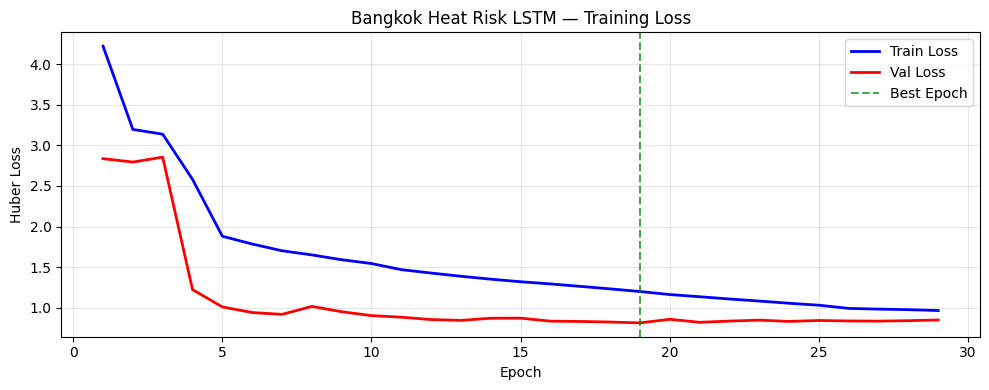

Best epoch: 19 | Best val loss: 0.8125


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_done = range(1, len(train_losses) + 1)
ax.plot(epochs_done, train_losses, 'b-', linewidth=2, label='Train Loss')
ax.plot(epochs_done, val_losses,   'r-', linewidth=2, label='Val Loss')
ax.axvline(np.argmin(val_losses)+1, color='g', linestyle='--', alpha=0.7, label='Best Epoch')
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title('Bangkok Heat Risk LSTM — Training Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve_bkk.png', dpi=120)
plt.show()
print(f"Best epoch: {np.argmin(val_losses)+1} | Best val loss: {min(val_losses):.4f}")

---
## Step 10 — พยากรณ์ 24h ทุกโซน

In [14]:
FORECAST_ZONE = "ใจกลาง"   # โซนหลักที่ใช้ใน Web App

# เกณฑ์กรมอุตุนิยมวิทยาไทย
WHO_HI_LEVELS = [
    (54, "อันตรายมาก", "ร้ายแรงต่อชีวิต"),
    (41, "อันตราย",    "เสี่ยง Heat Stroke สูง"),
    (32, "เตือนภัย",   "เสี่ยง Heat Exhaustion"),
    (27, "เฝ้าระวัง",  "อาจเกิดอ่อนเพลีย"),
    ( 0, "ปกติ",       "สภาพอากาศปกติ"),
]

def get_risk_level(hi):
    for threshold, label, desc in WHO_HI_LEVELS:
        if hi >= threshold:
            return label, desc
    return "ปกติ", "สภาพอากาศปกติ"

def hazard_score(hi):
    return float(np.clip((hi - 27.0) / (54.0 - 27.0), 0, 1))

model.eval()
zone_results = {}

print("พยากรณ์ 24h (Heat Index สูงสุด) แต่ละโซน:")
print("-" * 55)

for zone_name, *_ in ZONES:
    zdf_z  = df[df["zone"] == zone_name].reset_index(drop=True)
    X_z_sc = scaler.transform(zdf_z[FEATURES].values)
    win_z  = torch.tensor(X_z_sc[-TIME_STEPS:][np.newaxis], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred24 = model(win_z).cpu().numpy()[0]

    daily_max = float(np.max(pred24))
    level, desc = get_risk_level(daily_max)
    score = hazard_score(daily_max)

    zone_results[zone_name] = {
        "pred24":    pred24,
        "daily_max": daily_max,
        "level":     level,
        "score":     score
    }
    print(f"  {zone_name:12s}  HI max={daily_max:.1f}°C  [{level}]  score={score:.3f}")

# เก็บ P50/P95 สำหรับ config
DAILY_MAX    = zone_results[FORECAST_ZONE]["daily_max"]
HAZARD_SCORE = hazard_score(DAILY_MAX)
pred24_arr   = zone_results[FORECAST_ZONE]["pred24"]
print(f"\nโซนหลัก ({FORECAST_ZONE}): HI={DAILY_MAX:.1f}°C  Score={HAZARD_SCORE:.3f}")

พยากรณ์ 24h (Heat Index สูงสุด) แต่ละโซน:
-------------------------------------------------------
  ใจกลาง        HI max=38.8°C  [เตือนภัย]  score=0.439
  เหนือ         HI max=37.5°C  [เตือนภัย]  score=0.389
  ใต้           HI max=37.1°C  [เตือนภัย]  score=0.375
  ตะวันออก      HI max=37.6°C  [เตือนภัย]  score=0.392
  ตะวันตก       HI max=38.6°C  [เตือนภัย]  score=0.431

โซนหลัก (ใจกลาง): HI=38.8°C  Score=0.439


---
## Step 11 — ประชากรผู้สูงอายุ 50 เขต

In [16]:
# pop_raw มีข้อมูลอายุ 60-102+ แยกชาย/หญิง
# คอลัมน์: อำเภอ, ชาย60ปี, หญิง60ปี, ..., ชายรวม, หญิงรวม, รวมทั้งหมด

def clean_num(x):
    """แปลง '12,345' หรือ '-' → int"""
    if pd.isna(x) or str(x).strip() in ('', '-', '0'):
        return 0
    try:
        return int(str(x).replace(',', '').strip())
    except ValueError:
        return 0

pop_df = pop_raw.copy()
pop_df['district_clean'] = pop_df['อำเภอ'].str.replace('เขต', '', regex=False).str.strip()
pop_df['elderly_60_plus'] = pop_df['รวมทั้งหมด'].apply(clean_num)

# คำนวณ 70+ เพื่อ vulnerability score (เสี่ยงสูงกว่า)
age_cols_70up = []
for age in range(70, 103):
    male_col   = f'ชาย{age} ปี'
    female_col = f'หญิง{age} ปี'
    if male_col   in pop_df.columns: age_cols_70up.append(male_col)
    if female_col in pop_df.columns: age_cols_70up.append(female_col)

# applymap deprecated ใน pandas >= 2.1 → ใช้ map แทน
pop_df['elderly_70_plus'] = pop_df[age_cols_70up].map(clean_num).sum(axis=1)

# Vulnerability Score: 0.7 × 70+ratio + 0.3 × density proxy
pop_df['elderly_pct_70'] = pop_df['elderly_70_plus'] / (pop_df['elderly_60_plus'] + 1)
pop_df['vuln_score']     = np.clip(
    0.7 * pop_df['elderly_pct_70'] + 0.3 * (pop_df['elderly_60_plus'] / pop_df['elderly_60_plus'].max()),
    0, 1
)

pop_sum = pop_df[['district_clean','elderly_60_plus','elderly_70_plus',
                   'elderly_pct_70','vuln_score']].copy()
pop_sum.columns = ['district_clean','elderly_pop','elderly_70_plus',
                    'elderly_pct_70','vuln_score']

print(f"Population data: {len(pop_sum)} เขต")
display(pop_sum.sort_values('elderly_pop', ascending=False).head(10))
print(f"\nรวมผู้สูงอายุ 60+ ทั้ง กทม: {pop_sum['elderly_pop'].sum():,} คน")

Population data: 50 เขต


,district_clean,elderly_pop,elderly_70_plus,elderly_pct_70,vuln_score
39,บางแค,45210,19068,0.421756,0.595229
41,สายไหม,40240,16157,0.401506,0.548075
4,บางเขน,40044,17333,0.432838,0.568707
29,จตุจักร,37445,19146,0.511296,0.606381
34,จอมทอง,35270,15911,0.451107,0.549816
31,ประเวศ,32943,14497,0.440050,0.526635
20,บางขุนเทียน,32844,12839,0.390897,0.491571
28,บางซื่อ,32796,16229,0.494832,0.564007
35,ดอนเมือง,31957,13067,0.408880,0.498273
45,คลองสามวา,31876,11082,0.347649,0.454874



รวมผู้สูงอายุ 60+ ทั้ง กทม: 1,221,733 คน


---
## Step 12 — รวม GeoJSON + Population + Risk Score

In [18]:
# ── โหลด GeoJSON (แปลงจาก TopoJSON แล้ว) ─────────────────────
boundary = gpd.read_file(BOUNDARY_FILE)
if boundary.crs is None:
    boundary = boundary.set_crs(epsg=4326)
else:
    boundary = boundary.to_crs(epsg=4326)

print("Boundary columns:", boundary.columns.tolist())

# ─ ทำ district_clean จาก dname ─
boundary['district_clean'] = (
    boundary['dname']
    .str.replace('เขต', '', regex=False)
    .str.strip()
)

# ─ แก้ spelling ราษฎร์บูรณะ (TopoJSON ต้นฉบับสะกดผิด) ─
boundary['district_clean'] = boundary['district_clean'].replace({
    'ราษฏร์บูรณะ': 'ราษฎร์บูรณะ'
})

# ─ Merge ─
merged = boundary.merge(pop_sum, on='district_clean', how='left')
merged['elderly_pop']  = merged['elderly_pop'].fillna(0).astype(int)
merged['vuln_score']   = merged['vuln_score'].fillna(0.0)

# ─ Combined Risk (อากาศ × ประชากรเสี่ยง) ─
merged['combined_risk'] = np.clip(
    HAZARD_SCORE * 0.6 + merged['vuln_score'] * 0.4, 0, 1
)

# ─ Risk Level ─
def risk_label(r):
    if r >= 0.6: return "สูงมาก"
    if r >= 0.4: return "สูง"
    if r >= 0.2: return "ปานกลาง"
    return "ต่ำ"

merged['risk_level']      = merged['combined_risk'].apply(risk_label)
merged['heat_index_pred'] = DAILY_MAX

b_names   = set(boundary['district_clean'])
pop_names = set(pop_sum['district_clean'])
print(f"Boundary  : {len(b_names)} เขต")
print(f"Population: {len(pop_names)} เขต")
print(f"Match     : {len(b_names & pop_names)} เขต")
unmatch = b_names - pop_names
if unmatch: print(f"ไม่ match : {unmatch}")
print(f"\nmerged: {len(merged)} rows")
display(merged[['district_clean','elderly_pop','vuln_score',
                'combined_risk','risk_level']].sort_values('combined_risk', ascending=False).head(10))

Boundary columns: ['AREA', 'dcode', 'dname', 'dname_e', 'geometry']
Boundary  : 50 เขต
Population: 50 เขต
Match     : 50 เขต

merged: 50 rows


,district_clean,elderly_pop,vuln_score,combined_risk,risk_level
42,จตุจักร,37445,0.606381,0.505841,สูง
15,บางแค,45210,0.595229,0.501380,สูง
41,บางเขน,40044,0.568707,0.490772,สูง
46,บางซื่อ,32796,0.564007,0.488892,สูง
29,จอมทอง,35270,0.549816,0.483215,สูง
38,สายไหม,40240,0.548075,0.482519,สูง
10,บางกอกน้อย,29668,0.541099,0.479729,สูง
7,ดุสิต,22735,0.533344,0.476627,สูง
45,ลาดพร้าว,28429,0.531925,0.476059,สูง
24,ประเวศ,32943,0.526635,0.473943,สูง


---
## Step 13 — กราฟ Heat Index 24h + Risk Bar

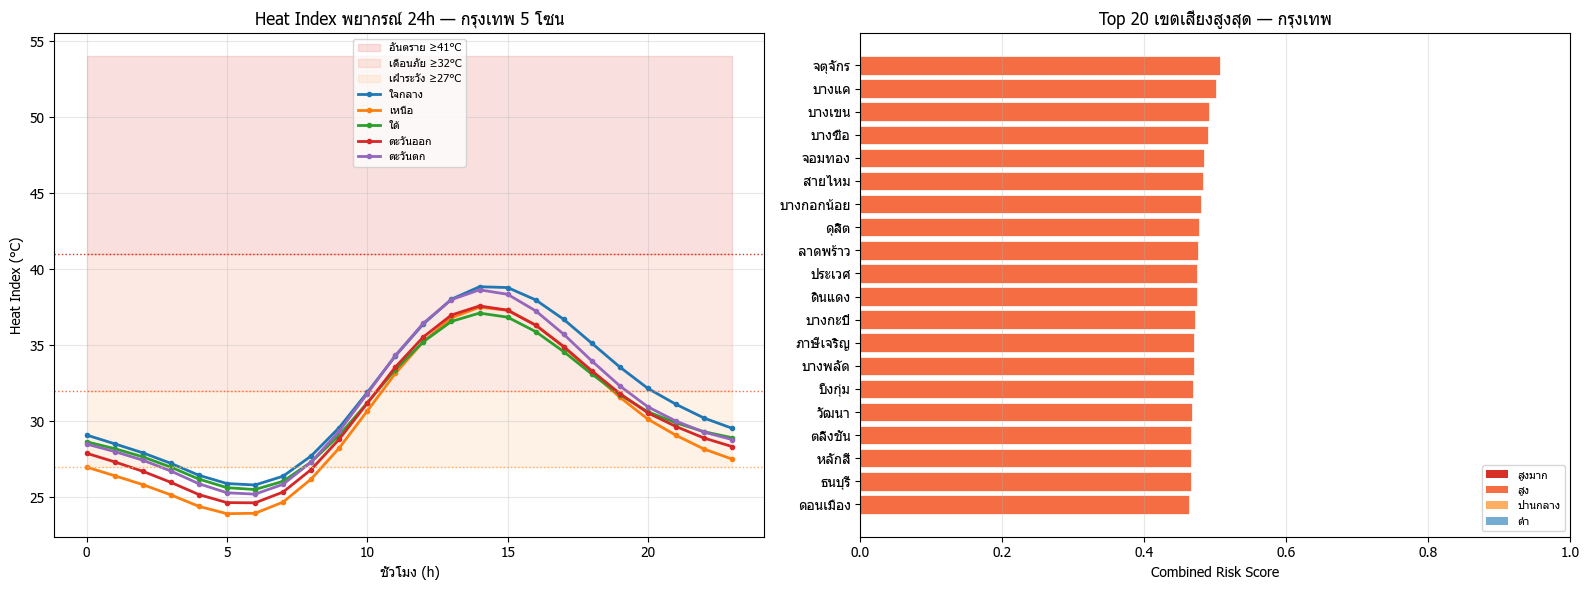

บันทึกภาพ: bangkok_heat_risk.png


In [19]:
import glob
from matplotlib import font_manager
import matplotlib
from matplotlib.patches import Patch

# Thai Font
thai_fonts = (glob.glob('C:/Windows/Fonts/THSarabun*.ttf') +
              glob.glob('C:/Windows/Fonts/Tahoma*.ttf'))
if thai_fonts:
    for fp in thai_fonts:
        font_manager.fontManager.addfont(fp)
    prop = font_manager.FontProperties(fname=thai_fonts[0])
    matplotlib.rcParams['font.family'] = prop.get_name()
matplotlib.rcParams['axes.unicode_minus'] = False

COLORS = {'สูงมาก':'#d73027','สูง':'#f46d43','ปานกลาง':'#fdae61','ต่ำ':'#74add1'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─ Plot 1: Heat Index 24h ─
ax1 = axes[0]
hours = list(range(24))
ax1.fill_between(hours, 41, 54, alpha=.15, color='#d73027', label='อันตราย ≥41°C')
ax1.fill_between(hours, 32, 41, alpha=.15, color='#f46d43', label='เตือนภัย ≥32°C')
ax1.fill_between(hours, 27, 32, alpha=.15, color='#fdae61', label='เฝ้าระวัง ≥27°C')
for zn, zres in zone_results.items():
    ax1.plot(hours, zres['pred24'], linewidth=2, label=zn, marker='o', markersize=3)
ax1.axhline(27, color='#fdae61', linestyle=':', linewidth=1)
ax1.axhline(32, color='#f46d43', linestyle=':', linewidth=1)
ax1.axhline(41, color='#d73027', linestyle=':', linewidth=1)
ax1.set_xlabel('ชั่วโมง (h)'); ax1.set_ylabel('Heat Index (°C)')
ax1.set_title('Heat Index พยากรณ์ 24h — กรุงเทพ 5 โซน')
ax1.legend(fontsize=8); ax1.grid(alpha=.3)

# ─ Plot 2: Top 20 เขตเสี่ยงสูง ─
ax2 = axes[1]
top20 = merged.nlargest(20, 'combined_risk').sort_values('combined_risk')
bar_colors = [COLORS[r] for r in top20['risk_level']]
ax2.barh(top20['district_clean'], top20['combined_risk'], color=bar_colors, edgecolor='white', linewidth=.5)
ax2.set_xlabel('Combined Risk Score')
ax2.set_title('Top 20 เขตเสี่ยงสูงสุด — กรุงเทพ')
ax2.legend(handles=[Patch(facecolor=v, label=k) for k,v in COLORS.items()], fontsize=8, loc='lower right')
ax2.set_xlim(0, 1); ax2.grid(axis='x', alpha=.3)

plt.tight_layout()
plt.savefig('bangkok_heat_risk.png', dpi=120, bbox_inches='tight')
plt.show()
print("บันทึกภาพ: bangkok_heat_risk.png")

---
## Step 14 — แผนที่ Folium

In [20]:
import folium
from folium.plugins import HeatMap
import matplotlib.cm as cm
import matplotlib.colors as mcolors

_vmin = float(merged['combined_risk'].min())
_vmax = float(merged['combined_risk'].max()) + 1e-8
_norm = mcolors.Normalize(vmin=_vmin, vmax=_vmax)
_cmap = cm.get_cmap('YlOrRd')

def risk_color(val):
    return mcolors.to_hex(_cmap(_norm(float(val))))

cx = float(merged.geometry.centroid.x.mean())
cy = float(merged.geometry.centroid.y.mean())
m  = folium.Map(location=[cy, cx], zoom_start=11, tiles='CartoDB positron')

top5 = merged.nlargest(5, 'combined_risk')['district_clean'].tolist()

risk_layer = folium.FeatureGroup(name='Heat Risk', show=True)
folium.GeoJson(
    merged,
    style_function=lambda feat: {
        'fillColor':   risk_color(feat['properties'].get('combined_risk', 0)),
        'color':       '#ffffff' if feat['properties'].get('district_clean') in top5 else '#555',
        'weight':      2.5      if feat['properties'].get('district_clean') in top5 else 0.8,
        'fillOpacity': 0.80,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['district_clean','risk_level','combined_risk','elderly_pop','heat_index_pred'],
        aliases=['เขต','ระดับความเสี่ยง','Risk Score','ผู้สูงอายุ 60+ (คน)','Heat Index พยากรณ์ (°C)'],
        localize=True
    )
).add_to(risk_layer)
risk_layer.add_to(m)

# Top 5 Markers
for _, row in merged.nlargest(5, 'combined_risk').iterrows():
    cx_d = row.geometry.centroid.x
    cy_d = row.geometry.centroid.y
    folium.CircleMarker(
        location=[cy_d, cx_d],
        radius=10,
        color='#7f0000', fill=True, fill_color='#ff4444', fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>{row['district_clean']}</b><br>"
            f"Risk Score: {row['combined_risk']:.3f}<br>"
            f"ระดับ: {row['risk_level']}<br>"
            f"ผู้สูงอายุ 60+: {row['elderly_pop']:,} คน",
            max_width=200
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
map_file = 'bangkok_heat_risk_map.html'
m.save(map_file)
print(f"บันทึกแผนที่: {map_file}")
m

บันทึกแผนที่: bangkok_heat_risk_map.html


C:\Users\Admin\AppData\Local\Temp\ipykernel_29032\1997176756.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = cm.get_cmap('YlOrRd')
C:\Users\Admin\AppData\Local\Temp\ipykernel_29032\1997176756.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cx = float(merged.geometry.centroid.x.mean())
C:\Users\Admin\AppData\Local\Temp\ipykernel_29032\1997176756.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cy = float(merged.geometry.centroid.y.mean())


---
## Step 15 — Export Model + GeoJSON สำหรับ Web App

In [21]:
os.makedirs('heat_risk_bkk_export', exist_ok=True)

MODEL_PATH  = 'heat_risk_bkk_export/model.pt'
SCALER_PATH = 'heat_risk_bkk_export/scaler.pkl'
CONFIG_PATH = 'heat_risk_bkk_export/config.json'
GEOJSON_PATH = 'heat_risk_bkk_export/grid.geojson'

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'input_size':  len(FEATURES),
        'hidden_size': 128,
        'num_layers':  2,
        'horizon':     HORIZON,
        'dropout':     0.2
    }
}, MODEL_PATH)
print(f"model.pt saved")

# Save scaler
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
print(f"scaler.pkl saved")

# Save config
config = {
    'time_steps':    TIME_STEPS,
    'horizon':       HORIZON,
    'features':      FEATURES,
    'p50':           round(P50, 3),
    'p95':           round(P95, 3),
    'zones':         [[z, lat, lon, elev] for z, lat, lon, elev in ZONES],
    'forecast_zone': FORECAST_ZONE,
    'model_file':    'model.pt',
    'framework':     'pytorch',
    'area':          'bangkok',
    'start_date':    START_DATE,
    'end_date':      END_DATE,
}
with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print(f"config.json saved")

# Save GeoJSON
geo_out = merged[['district_clean','dname','dcode','elderly_pop',
                   'vuln_score','combined_risk','risk_level',
                   'heat_index_pred','geometry']].copy()
geo_out = geo_out.rename(columns={'district_clean':'tambon_clean'})
geo_out.to_file(GEOJSON_PATH, driver='GeoJSON')
print(f"grid.geojson saved — {len(geo_out)} เขต")

# Zip ทั้งหมด
zip_path = 'heat_risk_bkk_export.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in [MODEL_PATH, SCALER_PATH, CONFIG_PATH, GEOJSON_PATH]:
        zf.write(fname, os.path.basename(fname))
print(f"\nzip: {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
print("\nExport เสร็จสมบูรณ์  — วางไฟล์ใน heat_risk_app_30/ แทนไฟล์เชียงใหม่ได้เลย")
print("   model.pt   → heat_risk_app_30/model.pt")
print("   scaler.pkl → heat_risk_app_30/scaler.pkl")
print("   config.json→ heat_risk_app_30/config.json")
print("   grid.geojson → heat_risk_app_30/grid.geojson")

model.pt saved
scaler.pkl saved
config.json saved
grid.geojson saved — 50 เขต

zip: heat_risk_bkk_export.zip  (0.9 MB)

Export เสร็จสมบูรณ์  — วางไฟล์ใน heat_risk_app_30/ แทนไฟล์เชียงใหม่ได้เลย
   model.pt   → heat_risk_app_30/model.pt
   scaler.pkl → heat_risk_app_30/scaler.pkl
   config.json→ heat_risk_app_30/config.json
   grid.geojson → heat_risk_app_30/grid.geojson
